<a href="https://colab.research.google.com/github/borgesjose/Grover_Algorithm/blob/main/Algoritmo__de__Grover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Algoritmo de Grover em problemas computacionais**

**Atividade:** UA01 e UA02 — Roteiro hands-on — Algoritmos Quânticos

Aluno: José Borges do Carmo Neto; https://github.com/borgesjose

Link do github: [Notebook Salvo](https://github.com/borgesjose/Grover_Algorithm/blob/3189437e7373dc336f2c820f24cd6223cbdad349/Algoritmo__de__Grover.ipynb)

**Data:** agosto de 2026

## Objetivos de aprendizagem
- Implementar o código do algoritmo de Grover em Python;
- Explicar o papel do oráculo no algoritmo de Grover;

- Explicar limitações e aspectos de escalabilidade do algoritmo.

## Sumário
1. Introdução e fundamentos do Algoritmo de Grover
2. Preparação e configuração do ambiente de simulação
3. Implementação do Algoritmo de Grover
4. Execucao, medicao e registro dos resultados
5. Impacto do ruido
6. Impacto do numero de shots
7. custo classico x quantico e estimativa do N de cruzamento
8. Consolidacao dos resultados



## 1. Introdução e fundamentos do Algoritmo de Grover

O Algoritmo de Grover é um algoritmo quântico de busca não estruturada que oferece uma aceleração quadrática em relação aos métodos clássicos, reduzindo a complexidade de tempo de $O(N)$ para $O(\sqrt{N})$. Essa vantagem decorre do aproveitamento da mecânica quântica para manipular amplitudes de probabilidade por meio de interferência construtiva e destrutiva.

**Superposição e Inicialização**
O processo começa aplicando a porta Hadamard ($H$) a todos os $n$ qubits inicializados no estado $\vert{}0\rangle$. Isso cria um estado de superposição uniforme, no qual o sistema representa simultaneamente todos os $N = 2^n$ estados possíveis da base de dados com a mesma amplitude de probabilidade $1/\sqrt{N}$.

**O Papel do Oráculo e sua Criação**
O oráculo é uma função caixa-preta $f(x)$ encarregada de reconhecer se uma dada entrada $x$ é a solução procurada ($f(x) = 1$) ou não ($f(x) = 0$). Em vez de medir e revelar o resultado, o oráculo atua alterando a fase do estado correto. Ele é definido pela transformação:

$$U_w \vert{}x\rangle = (-1)^{f(x)} \vert{}x\rangle$$

Para criar o oráculo na prática, implementa-se um circuito lógico quântico (utilizando portas como CNOT, Toffoli ou portas personalizadas) que mapeia a condição do problema. Utiliza-se frequentemente a técnica de *phase kickback* com um qubit auxiliar no estado $\vert{}-\rangle$, permitindo inverter o sinal (fase) da amplitude do estado alvo de positivo para negativo sem alterar a de nenhum outro estado.

**Amplificação de Amplitude**
Após a marcação pelo oráculo, o algoritmo aplica o operador de difusão de Grover, também conhecido como reflexão em torno da média. Esse operador calcula a média das amplitudes de todos os estados e inverte cada amplitude em relação a essa média. Como o oráculo tornou a amplitude da solução negativa, a reflexão eleva significativamente o valor absoluto dessa amplitude positiva, enquanto atenua as amplitudes das respostas incorretas.

**Número de Iterações Ideais**
A cada aplicação do conjunto "Oráculo + Difusor", o vetor de estado do sistema é rotacionado no espaço de Hilbert em direção ao estado da solução. Essa rotação não é infinita: aplicar o operador vezes demais faz o vetor passar do ponto ideal (sobre-rotação), reduzindo a probabilidade de sucesso. O número ótimo de iterações $r$ para obter a probabilidade máxima de medição é calculado por:

$$r = \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{k}} \right\rfloor$$

onde $k$ representa o número de alvos/soluções presentes no espaço de busca $N$.




## 2. Preparação e configuração do ambiente de simulação

In [1]:
# Instalação do Qskit;
!pip install qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 96.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.8 MB/s eta 0:00:00


In [33]:
# Chamada das bibliotecas:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import math

%matplotlib inline


## 3. Implementação do Algoritmo de Grover:

Para a implementação do algoritmo de Grover, adotou-se a filosofia de desenvolvimento orientado a funções.

Foram desenvolvidos as seguintes funções básicas:

```python
apply_multi_controlled_z(qc, qubits)
```
```python
build_oracle(n, targets)
```
```python
build_diffuser(n)
```
```python
num_iterations(n, k)
```
```python
grover_circuit(n, targets, r=None)
```

### Porta Z multicontrolada


```python
apply_multi_controlled_z(qc, qubits)
```
Essa função tem um papel central para o desenvolvimento do algoritmo. Nela é implementada uma porta Z multi-controlada. Ela tem como função:

*   Aplicar uma porta Z (fase) a um qubit alvo, mas apenas se todos os qubits de controle estiverem no estado $|1\rangle$.
*   É uma construção fundamental para oráculos de Grover, pois permite alterar a fase dos estados desejados na superposição.
*   A implementação aplica Hadamard (H) no qubit alvo, depois um MCX (multi-controlado X, similar a uma Toffoli) e, por fim, outro H. Isso se baseia na identidade $HZH = X$ e $HXH = Z$, permitindo construir um CZ a partir de um CX e Hadamards.

In [3]:
def apply_multi_controlled_z(qc, qubits):
  if len(qubits) == 1:
        qc.z(qubits[0])
        return
  controls = qubits[:-1]
  target = qubits[-1]
  qc.h(target)
  qc.mcx(controls, target)
  qc.h(target)

### Oraculo

```python
build_oracle(n, targets)
```


In [4]:
def build_oracle(n, targets):
    qc = QuantumCircuit(n, name="Oraculo")
    for t in targets:
        bits = format(t, f"0{n}b")   # ex: n=3, t=5 -> '101'
        # descobrir quais posicoes de qubit (0 a n-1) tem bit '0' no alvo,
        # lembrando da inversao little-endian (bits[n-1-i] corresponde a qubit[i])
        qubits_to_flip = []
        for i in range(n):
            if bits[n - 1 - i] == '0':
                qc.x(i)
                qubits_to_flip.append(i)

        # aplicar a porta z multicontrolada
        apply_multi_controlled_z(qc, list(range(n)))

        # desfazer os X (mesma lista de antes)
        for i in qubits_to_flip:
            qc.x(i)
    return qc

### Difusor

```python
build_diffuser(n)
```


In [5]:
def build_diffuser(n):
    qc = QuantumCircuit(n, name="Difusor")
    # H em todos os qubits
    qc.h(range(n))
    # X em todos os qubits
    qc.x(range(n))
    # apply_multi_controlled_z nos n qubits
    apply_multi_controlled_z(qc, list(range(n)))
    # X em todos os qubits
    qc.x(range(n))
    # H em todos os qubits
    qc.h(range(n))

    return qc

### Iterações maxima:

```python
num_iterations(n, k)
```

In [6]:
def num_iterations(n, k):
    N = 2 ** n
    r = np.floor(np.pi / 4 * np.sqrt(N / k))
    return int(r)

### Circuito de Grover

```python
grover_circuit(n, targets, r=None)
```

In [7]:
def grover_circuit(n, targets, r=None):
    k = len(targets)
    if r is None:
        r = num_iterations(n, k)
    qc = QuantumCircuit(n, n)
    # H em todos os qubits (superposicao inicial)
    qc.h(range(n))
    oracle = build_oracle(n, targets)
    diffuser = build_diffuser(n)
    for _ in range(r):
        # aplicar oracle no circuito (use qc.compose(oracle, range(n), inplace=True))
        qc.compose(oracle, range(n), inplace=True)
        # aplicar diffuser da mesma forma
        qc.compose(diffuser, range(n), inplace=True)
    # medir todos os qubits nos bits classicos correspondentes
    qc.measure(range(n), range(n))
    return qc, r

## 4. Execucao, medicao e registro dos resultados:
Para atender todos os pontos solicitados no hand on foi criada a função  `run_grover_experiment` que roda o circuito, mede o tempo, calcula a fidelidade
(probabilidade total nos estados-alvo) e devolve tudo organizado para registro.

In [8]:
registro_experimentos = []  # lista para consolidar todos os resultados (secao 13)

def target_bitstrings(n, targets):
    return {format(t, f"0{n}b") for t in targets}

def prob_nos_alvos(counts, n, targets, shots):
    alvos_bin = target_bitstrings(n, targets)
    return sum(counts.get(b, 0) for b in alvos_bin) / shots

def run_grover_experiment(n, targets, shots=1024, noise_model=None, label="", r=None,
                           salvar_figuras=True, mostrar=True):
    """Executa um cenario completo do algoritmo de Grover e retorna um dicionario com os
    resultados (Subpasso 2.5: rodar o circuito e imprimir tempo, iteracoes e histograma).
    """
    qc, r_usado = grover_circuit(n, targets, r=r)
    sim = AerSimulator(noise_model=noise_model)

    t0 = time.perf_counter()
    result = sim.run(qc, shots=shots).result()
    t1 = time.perf_counter()
    tempo_execucao = t1 - t0

    counts = result.get_counts()
    fidelidade = prob_nos_alvos(counts, n, targets, shots)

    condicao = "com ruido" if noise_model else "ideal"
    titulo = label if label else f"n={n}, alvos={targets}"

    if mostrar:
        print(f"--- {titulo} ({condicao}, shots={shots}) ---")
        print(f"N = 2^{n} = {2**n} | k = {len(targets)} alvo(s) | r = {r_usado} iteracoes")
        print(f"Tempo de execucao (simulacao): {tempo_execucao:.4f} s")
        print(f"Probabilidade total nos estados-alvo: {fidelidade:.4f}")
        top5 = sorted(counts.items(), key=lambda kv: -kv[1])[:5]
        print("Estados mais frequentes:", top5)

    fig_hist = None
    if salvar_figuras:
        fig_hist = plot_histogram(counts, figsize=(9, 4), title=f"{titulo} | shots={shots} | {condicao}")
        label_arquivo = titulo.replace(" ", "_")
        nome_arquivo = f"hist_{label_arquivo}_{shots}_{condicao.replace(' ', '_')}.png"
        fig_hist.savefig(nome_arquivo, bbox_inches="tight", dpi=110)
        if mostrar:
            plt.show()
        else:
            plt.close(fig_hist)

    registro = dict(
        label=label, n=n, N=2 ** n, targets=list(targets), k=len(targets), r=r_usado,
        shots=shots, ruido=noise_model is not None, tempo_execucao_s=tempo_execucao,
        fidelidade=fidelidade, counts=counts,
    )
    registro_experimentos.append(registro)
    return registro, qc

### 4.1. Cenario 1

Vslidação do funcionamento do circuito em baixa escala: o estado-alvo deve aparecer com
probabilidade proxima de 100% nas medicoes. Usando 2 qbits e 1 alvo.

--- Cenario 1 (n=2, alvo=|11>) (ideal, shots=1024) ---
N = 2^2 = 4 | k = 1 alvo(s) | r = 1 iteracoes
Tempo de execucao (simulacao): 0.0031 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('11', 1024)]


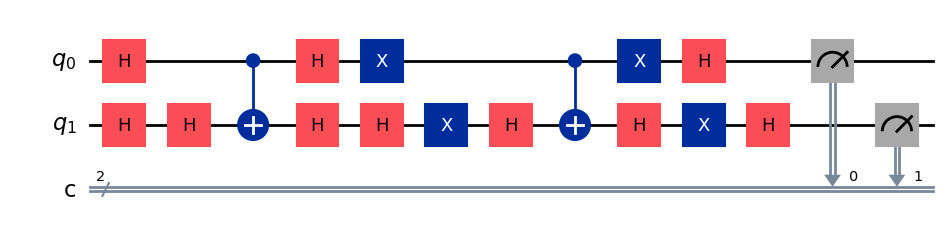

In [14]:
reg1, qc1 = run_grover_experiment(
    n=2, targets=[3], shots=1024, label="Cenario 1 (n=2, alvo=|11>)"
)
display(qc1.draw("mpl"))

### 4.2. Cenario 2

Alvo = $|111\ldots1\rangle = 2^{16}-1$. Alem da versao quantica, rodamos a busca classica linear
percorrendo todos os estados de 0 a $2^{16}-1$ e comparamos o tempo de execucao.

In [18]:
n2 = 16
alvo2 = 2 ** n2 - 1  # |111...1>

reg2, qc2 = run_grover_experiment(
    n=n2, targets=[alvo2], shots=1024, label="Cenario 2 (n=16, alvo=max)"
)


--- Cenario 2 (n=16, alvo=max) (ideal, shots=1024) ---
N = 2^16 = 65536 | k = 1 alvo(s) | r = 201 iteracoes
Tempo de execucao (simulacao): 3.7997 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('1111111111111111', 1024)]


Funcao de busca linear simples, que percorre os estados possiveis em ordem ate encontrar um alvo
(ou o primeiro alvo, no caso de multiplos). Registra numero de consultas e tempo de execucao.

In [20]:
def classical_linear_search(N, targets):
    """Busca linear classica: percorre 0, 1, ..., N-1 ate encontrar um dos alvos.
    Retorna (numero de consultas, tempo de execucao em segundos, alvo encontrado).
    """
    targets_set = set(targets)
    t0 = time.perf_counter()
    consultas = 0
    encontrado = None
    for x in range(N):
        consultas += 1
        if x in targets_set:
            encontrado = x
            break
    t1 = time.perf_counter()
    return consultas, t1 - t0, encontrado

Comparação entre a execução quantica e classica.

In [21]:
consultas_classicas2, tempo_classico2, encontrado2 = classical_linear_search(2 ** n2, [alvo2])
print(f"\nBusca classica linear: {consultas_classicas2} consultas, "
      f"{tempo_classico2:.6f} s, alvo encontrado={encontrado2}")
print(f"Busca quantica (Grover): {reg2['r']} iteracoes (consultas ao oraculo), "
      f"{reg2['tempo_execucao_s']:.6f} s de simulacao")

reg2["consultas_classicas"] = consultas_classicas2
reg2["tempo_classico_s"] = tempo_classico2


Busca classica linear: 65536 consultas, 0.005226 s, alvo encontrado=65535
Busca quantica (Grover): 201 iteracoes (consultas ao oraculo), 3.799740 s de simulacao


In [10]:
def classical_linear_search(N, targets):
    targets_set = set(targets)
    t0 = time.perf_counter()
    consultas = 0
    encontrado = None
    for x in range(N):
        consultas += 1
        if x in targets_set:
            encontrado = x
            break
    t1 = time.perf_counter()
    return consultas, t1 - t0, encontrado

In [11]:
n2 = 16
alvo2 = 2**n2 - 1   # |111...1>

t0 = time.perf_counter()
qc2, r2 = grover_circuit(n2, [alvo2])
sim = AerSimulator()
result2 = sim.run(qc2, shots=1024).result()
t1 = time.perf_counter()

counts2 = result2.get_counts()
print(f"r = {r2} iteracoes")
print(f"tempo quantico (simulacao): {t1 - t0:.4f} s")
print("estado mais frequente:", max(counts2, key=counts2.get))

consultas_c, tempo_c, encontrado_c = classical_linear_search(2**n2, [alvo2])
print(f"\nbusca classica: {consultas_c} consultas, {tempo_c:.6f} s")

r = 201 iteracoes
tempo quantico (simulacao): 3.7485 s
estado mais frequente: 1111111111111111

busca classica: 65536 consultas, 0.004334 s


### 4.3. Cenario 3

O objetivo aqui e observar os **limites da simulacao**: erros, lentidao ou travamentos ao aumentar
a escala. Aqui é feito o teste com valores cada vez maiores de Qbits, de acordo com a RAM e o tempo disponiveis na sua maquina/Colab.

In [22]:
N_QUBITS_CENARIO3 = [16, 18, 20, 22];

for n_teste in N_QUBITS_CENARIO3:

    alvo3 = 2 ** n_teste - 1

    print(f"Cenario 3: n={n_teste} qubits, N=2^{n_teste}={2**n_teste} estados")
    print("Isso pode levar de segundos a minutos dependendo do seu ambiente. Aguarde...")

    t_inicio = time.perf_counter()
    try:
        reg3, qc3 = run_grover_experiment(
            n=n_teste, targets=[alvo3], shots=256,
            label=f"Cenario 3 (n={n_teste}, limite de escala)",
            salvar_figuras=True,
        )
        print(f"\nSucesso. Tempo total da celula: {time.perf_counter() - t_inicio:.2f} s")
    except MemoryError as e:
        print(f"MemoryError: o ambiente nao tem RAM suficiente para n={n_teste}. "
              f"Reduza N_QUBITS_CENARIO3 e rode novamente. Detalhe: {e}")
    except Exception as e:
        print(f"Erro ao simular n={n_teste}: {type(e).__name__}: {e}. "
              f"Reduza N_QUBITS_CENARIO3 e rode novamente.")

Cenario 3: n=16 qubits, N=2^16=65536 estados
Isso pode levar de segundos a minutos dependendo do seu ambiente. Aguarde...
--- Cenario 3 (n=16, limite de escala) (ideal, shots=256) ---
N = 2^16 = 65536 | k = 1 alvo(s) | r = 201 iteracoes
Tempo de execucao (simulacao): 2.6156 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('1111111111111111', 256)]

Sucesso. Tempo total da celula: 2.76 s
Cenario 3: n=18 qubits, N=2^18=262144 estados
Isso pode levar de segundos a minutos dependendo do seu ambiente. Aguarde...
--- Cenario 3 (n=18, limite de escala) (ideal, shots=256) ---
N = 2^18 = 262144 | k = 1 alvo(s) | r = 402 iteracoes
Tempo de execucao (simulacao): 24.2190 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('111111111111111111', 256)]

Sucesso. Tempo total da celula: 24.40 s
Cenario 3: n=20 qubits, N=2^20=1048576 estados
Isso pode levar de segundos a minutos dependendo do seu ambiente. Aguarde...
--- Cenario 3 (n=20, limite de escala) (

### 4.4. Cenario 4

Alvos: estados $|00011\rangle=3$, $|00111\rangle=7$ e $|01011\rangle=11$ ($k=3$). O numero de
iteracoes usa a formula generalizada para $k>1$.

--- Cenario 4 (n=5, multiplos alvos) (ideal, shots=2048) ---
N = 2^5 = 32 | k = 3 alvo(s) | r = 2 iteracoes
Tempo de execucao (simulacao): 0.0067 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('01011', 703), ('00111', 697), ('00011', 648)]


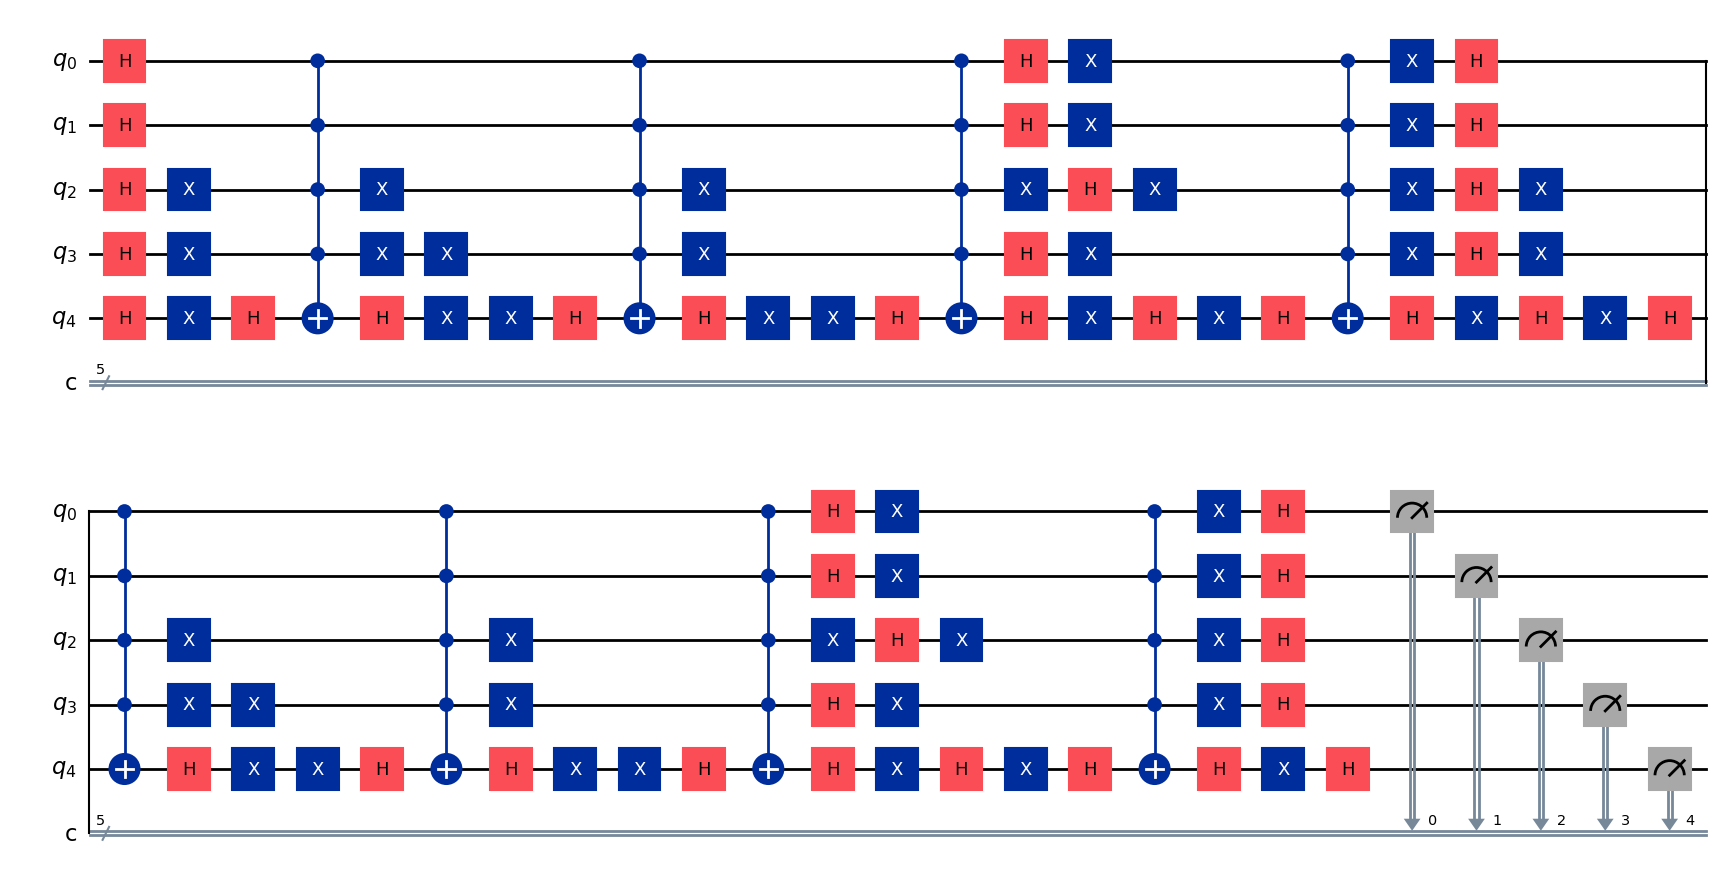


Distribuicao de probabilidade por alvo:
  |00011> (decimal 3): 0.3164
  |00111> (decimal 7): 0.3403
  |01011> (decimal 11): 0.3433


In [27]:
n4 = 5
alvos4 = [3, 7, 11]

reg4, qc4 = run_grover_experiment(
    n=n4, targets=alvos4, shots=2048, label="Cenario 4 (n=5, multiplos alvos)"
)
display(qc4.draw("mpl"))

print("\nDistribuicao de probabilidade por alvo:")
for t in alvos4:
    b = format(t, f"0{n4}b")
    p = reg4["counts"].get(b, 0) / reg4["shots"]
    print(f"  |{b}> (decimal {t}): {p:.4f}")


## 5. Impacto do ruido

Definimos um modelo de ruido simples (erro de despolarizacao) para portas de 1 e 2 qubits e
executamos pelo menos um dos circuitos com e sem ruido, comparando os resultados.

Usamos o **Cenario 4** (5 qubits) para essa comparacao inicial porque e rapido de simular mesmo
com ruido -- circuitos maiores (como o Cenario 2, com 201 iteracoes) ficam **muito** mais lentos
sob ruido, pois o simulador precisa decompor cada porta em portas elementares para inserir os
canais de erro (isso e discutido na secao 11).

In [28]:
def criar_modelo_de_ruido(p1=0.001, p2=0.01):
    """Modelo de ruido por despolarizacao: p1 = taxa de erro em portas de 1 qubit (h, x, z),
    p2 = taxa de erro em portas de 2 qubits (cx, e as portas internas do mcx)."""
    noise_model = NoiseModel()
    erro_1q = depolarizing_error(p1, 1)
    erro_2q = depolarizing_error(p2, 2)
    noise_model.add_all_qubit_quantum_error(erro_1q, ["h", "x", "z", "u1", "u2", "u3"])
    noise_model.add_all_qubit_quantum_error(erro_2q, ["cx"])
    return noise_model

modelo_ruido_padrao = criar_modelo_de_ruido(p1=0.001, p2=0.01)

print("=== Cenario 4 -- ideal ===")
reg4_ideal, _ = run_grover_experiment(
    n=5, targets=[3, 7, 11], shots=1024, label="Cenario 4 - ideal", salvar_figuras=False
)

print("\n=== Cenario 4 -- com ruido ===")
reg4_ruido, _ = run_grover_experiment(
    n=5, targets=[3, 7, 11], shots=1024, noise_model=modelo_ruido_padrao,
    label="Cenario 4 - com ruido", salvar_figuras=False
)

print(f"\nQueda de fidelidade por causa do ruido: "
      f"{reg4_ideal['fidelidade']:.4f} -> {reg4_ruido['fidelidade']:.4f} "
      f"(delta = {reg4_ideal['fidelidade'] - reg4_ruido['fidelidade']:.4f})")

=== Cenario 4 -- ideal ===
--- Cenario 4 - ideal (ideal, shots=1024) ---
N = 2^5 = 32 | k = 3 alvo(s) | r = 2 iteracoes
Tempo de execucao (simulacao): 0.0061 s
Probabilidade total nos estados-alvo: 1.0000
Estados mais frequentes: [('00111', 347), ('00011', 343), ('01011', 334)]

=== Cenario 4 -- com ruido ===
--- Cenario 4 - com ruido (com ruido, shots=1024) ---
N = 2^5 = 32 | k = 3 alvo(s) | r = 2 iteracoes
Tempo de execucao (simulacao): 0.3066 s
Probabilidade total nos estados-alvo: 0.9561
Estados mais frequentes: [('00111', 342), ('01011', 321), ('00011', 316), ('01111', 4), ('11011', 4)]

Queda de fidelidade por causa do ruido: 1.0000 -> 0.9561 (delta = 0.0439)


## 6. Impacto do numero de shots

Execute o Cenario 2 (16 qubits) e o Cenario 4 (5 qubits multiplos alvos) com e sem ruido, com
1, 100 e 1024 *shots*, observando variacoes no histograma, na frequencia de acertos e na confianca
estatistica.

In [30]:
LISTA_SHOTS = [1, 100, 1024]

RODAR_CENARIO2_RUIDO_COMPLETO = True  # mude para True se tiver tempo (pode levar dezenas de minutos)
LISTA_SHOTS_CENARIO2_RUIDO = LISTA_SHOTS if RODAR_CENARIO2_RUIDO_COMPLETO else [1, 10]

resultados_shots = []

def varrer_shots(n, targets, lista_shots, label_base):
    linhas = []
    for ruido in [None, modelo_ruido_padrao]:
        for shots in lista_shots:
            reg, _ = run_grover_experiment(
                n=n, targets=targets, shots=shots, noise_model=ruido,
                label=f"{label_base}", salvar_figuras=False, mostrar=False,
            )
            linhas.append(reg)
            resultados_shots.append(reg)
            condicao = "com ruido" if ruido else "ideal"
            print(f"{label_base:28s} | {condicao:10s} | shots={shots:5d} | "
                  f"fidelidade={reg['fidelidade']:.4f} | tempo={reg['tempo_execucao_s']:.3f}s")
    return linhas

print("### Cenario 4 (n=5, multiplos alvos) -- todos os shots, ideal e com ruido ###")
varrer_shots(5, [3, 7, 11], LISTA_SHOTS, "Cenario 4")

print("\n### Cenario 2 (n=16) -- shots sem ruido (rapido) ###")
for shots in LISTA_SHOTS:
    reg, _ = run_grover_experiment(
        n=16, targets=[2 ** 16 - 1], shots=shots, noise_model=None,
        label="Cenario 2", salvar_figuras=False, mostrar=False,
    )
    resultados_shots.append(reg)
    print(f"Cenario 2 (n=16)             | ideal      | shots={shots:5d} | "
          f"fidelidade={reg['fidelidade']:.4f} | tempo={reg['tempo_execucao_s']:.3f}s")

print("\n### Cenario 2 (n=16) -- shots COM ruido (lento) ###")
if not RODAR_CENARIO2_RUIDO_COMPLETO:
    print("RODAR_CENARIO2_RUIDO_COMPLETO=False -> usando lista reduzida de shots:",
          LISTA_SHOTS_CENARIO2_RUIDO, "para manter o tempo de execucao razoavel.")
for shots in LISTA_SHOTS_CENARIO2_RUIDO:
    t0 = time.perf_counter()
    reg, _ = run_grover_experiment(
        n=16, targets=[2 ** 16 - 1], shots=shots, noise_model=modelo_ruido_padrao,
        label="Cenario 2", salvar_figuras=False, mostrar=False,
    )
    resultados_shots.append(reg)
    print(f"Cenario 2 (n=16)             | com ruido  | shots={shots:5d} | "
          f"fidelidade={reg['fidelidade']:.4f} | tempo={reg['tempo_execucao_s']:.3f}s")

### Cenario 4 (n=5, multiplos alvos) -- todos os shots, ideal e com ruido ###
Cenario 4                    | ideal      | shots=    1 | fidelidade=1.0000 | tempo=0.004s
Cenario 4                    | ideal      | shots=  100 | fidelidade=1.0000 | tempo=0.005s
Cenario 4                    | ideal      | shots= 1024 | fidelidade=1.0000 | tempo=0.007s
Cenario 4                    | com ruido  | shots=    1 | fidelidade=1.0000 | tempo=0.005s
Cenario 4                    | com ruido  | shots=  100 | fidelidade=0.9700 | tempo=0.033s
Cenario 4                    | com ruido  | shots= 1024 | fidelidade=0.9395 | tempo=0.348s

### Cenario 2 (n=16) -- shots sem ruido (rapido) ###
Cenario 2 (n=16)             | ideal      | shots=    1 | fidelidade=1.0000 | tempo=4.725s
Cenario 2 (n=16)             | ideal      | shots=  100 | fidelidade=1.0000 | tempo=2.596s
Cenario 2 (n=16)             | ideal      | shots= 1024 | fidelidade=1.0000 | tempo=2.576s

### Cenario 2 (n=16) -- shots COM ruido (lento) 

## 7. Custo classico x quantico e estimativa do N de cruzamento

In [31]:
def tempo_medio_iteracao_grover(n, targets, repeticoes=5):
    tempos = []
    sim = AerSimulator()
    for _ in range(repeticoes):
        qc_iter, _ = grover_circuit(n, targets, r=1)   # forca r=1: uma iteracao so
        t0 = time.perf_counter()
        sim.run(qc_iter, shots=1).result()
        t1 = time.perf_counter()
        tempos.append(t1 - t0)
    return sum(tempos) / len(tempos)

def tempo_medio_consulta_classica(repeticoes=200000):
    alvo_fake = -1  # nunca bate, forcando N comparacoes reais
    t0 = time.perf_counter()
    for x in range(repeticoes):
        _ = (x == alvo_fake)
    t1 = time.perf_counter()
    return (t1 - t0) / repeticoes

tempo_q = tempo_medio_iteracao_grover(n=10, targets=[5])
tempo_c = tempo_medio_consulta_classica()

print(f"tempo medio 1 iteracao quantica (n=10): {tempo_q*1000:.4f} ms")
print(f"tempo medio 1 consulta classica: {tempo_c*1e9:.2f} ns")

razao = tempo_q / tempo_c
print(f"1 iteracao quantica custa ~{razao:,.0f}x mais tempo de parede que 1 consulta classica")

tempo medio 1 iteracao quantica (n=10): 3.0045 ms
tempo medio 1 consulta classica: 35.33 ns
1 iteracao quantica custa ~85,040x mais tempo de parede que 1 consulta classica


In [34]:
sqrt_N_cruzamento = (math.pi / 2) * razao
N_cruzamento = sqrt_N_cruzamento ** 2
n_cruzamento = math.log2(N_cruzamento)

print(f"N de cruzamento estimado: {N_cruzamento:,.0f}")
print(f"equivalente a n ~= {n_cruzamento:.1f} qubits")

N de cruzamento estimado: 17,843,892,535
equivalente a n ~= 34.1 qubits


## 8. Consolidacao dos resultados

Tabela-resumo com todos os experimentos rodados.

In [35]:
import pandas as pd

df = pd.DataFrame(registro_experimentos)
colunas_resumo = ["label", "n", "N", "k", "r", "shots", "ruido", "tempo_execucao_s", "fidelidade"]
df_resumo = df[colunas_resumo].copy()
df_resumo["tempo_execucao_s"] = df_resumo["tempo_execucao_s"].round(4)
df_resumo["fidelidade"] = df_resumo["fidelidade"].round(4)
df_resumo.to_csv("resumo_experimentos.csv", index=False)
df_resumo

,label,n,N,k,r,shots,ruido,tempo_execucao_s,fidelidade
0,"Cenario 1 (n=2, alvo=|11>)",2,4,1,1,1024,False,0.0034,1.0000
1,"Cenario 1 (n=2, alvo=|11>)",2,4,1,1,1024,False,0.0031,1.0000
2,"Cenario 1 (n=2, alvo=|11>)",2,4,1,1,1024,False,0.0034,1.0000
3,"Cenario 1 (n=2, alvo=|11>)",2,4,1,1,1024,False,0.0031,1.0000
4,"Cenario 2 (n=16, alvo=max)",16,65536,1,201,1024,False,4.7623,1.0000
5,"Cenario 2 (n=16, alvo=max)",16,65536,1,201,1024,False,2.6825,1.0000
6,"Cenario 2 (n=16, alvo=max)",16,65536,1,201,1024,False,4.3105,1.0000
7,"Cenario 2 (n=16, alvo=max)",16,65536,1,201,1024,False,3.7997,1.0000
8,"Cenario 3 (n=16, limite de escala)",16,65536,1,201,256,False,2.6156,1.0000
9,"Cenario 3 (n=18, limite de escala)",18,262144,1,402,256,False,24.2190,1.0000
